# Imports & Initialisation

In [63]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import h5py
import os
from pathlib import Path
from zoneinfo import ZoneInfo
from datetime import datetime, timezone, timedelta
from scipy.signal import savgol_filter
from scipy.signal import welch
    
%matplotlib inline


## Functions

In [64]:
def load_data(filename, calibration=1.0):
    extension = os.path.splitext(filename)[1].lower()

    if extension == ".h5":
        with h5py.File(filename, "r") as f:
            return {
                "x": f["x"][:] * calibration,
                "y": f["y"][:] * calibration,
                "z": f["z"][:] * calibration,
                "time": f["time_s"][:],
                "start_unix": float(f.attrs["start_time_unix"])
            }

    if extension == ".csv":
        data = pd.read_csv(filename, skiprows=1)
        timestamps = pd.to_datetime(
            data["yyyy-MM-dd HH:mm:ss"]
        ).dt.tz_localize("Australia/Sydney")

        return {
            "x": data["X (nT)"].to_numpy() * calibration,
            "y": data["Y (nT)"].to_numpy() * calibration,
            "z": data["Z (nT)"].to_numpy() * calibration,
            "time": (
                timestamps - timestamps.iloc[0]
            ).dt.total_seconds().to_numpy(),
            "start_unix": timestamps.iloc[0].timestamp()
        }

    raise ValueError(f"Unsupported file type: {extension}")

In [65]:
def PCAThetaFinder(targetFile, axis1, axis2, calibration=1.0):
    data = load_data(targetFile, calibration)

    B1, B2 = data[axis1], data[axis2]
    unix_time = data["start_unix"] + data["time"]

    covariance = np.cov(B1, B2)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    principal_vector = eigenvectors[:, np.argmax(eigenvalues)]
    max_variance = np.max(eigenvalues)

    theta = np.degrees(np.arctan2(
        principal_vector[1],
        principal_vector[0]
    ))
    if theta < 0:
        theta += 180

    B1_mean, B2_mean = np.mean(B1), np.mean(B2)
    theta_rad = np.radians(theta)

    B_theta = (
        (B1 - B1_mean) * np.cos(theta_rad)
        + (B2 - B2_mean) * np.sin(theta_rad)
        + B1_mean * np.cos(theta_rad)
        + B2_mean * np.sin(theta_rad)
    )

    return theta, np.std(B_theta), max_variance, B_theta, unix_time

In [66]:
def plotTheta(targetFile, axis1, axis2, calibration=1.0):
    theta, std, variance, B, unix_time = PCAThetaFinder(
        targetFile, axis1, axis2, calibration
    )

    print(f"Best theta: {theta:.1f} degrees")
    print(f"Standard deviation: {std:.4f} nT")
    print(f"Maximum variance: {variance:.4f} nT²")

    B = savgol_filter(B, 101, 3)

    sydney = ZoneInfo("Australia/Sydney")
    plot_step = max(1, len(B) // 100_000)

    time_sydney = [
        datetime.fromtimestamp(float(t), tz=sydney)
        for t in unix_time[::plot_step]
    ]

    plt.figure(figsize=(12, 5))
    plt.plot(time_sydney, B[::plot_step], linewidth=1)

    plt.xlabel("Sydney time")
    plt.ylabel("Magnetic field (nT)")
    plt.title(f"Optimal projection: {axis1} + {axis2} (θ = {theta:.1f}°)")

    ax = plt.gca()
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M:%S", tz=sydney)
    )
    ax.tick_params(axis="x", rotation=45)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [67]:
def plotAxes(targetFile, calibration=1.0, smooth=True):
    data = load_data(targetFile, calibration)

    B = [data["x"], data["y"], data["z"]]
    time = data["start_unix"] + data["time"]

    if smooth:
        B = [savgol_filter(b, 101, 1) for b in B]

    max_plot_points = 100_000
    plot_step = max(1, len(time) // max_plot_points)

    sydney = ZoneInfo("Australia/Sydney")
    time_sydney = [
        datetime.fromtimestamp(float(t), tz=sydney)
        for t in time[::plot_step]
    ]

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    for ax, b, color, label in zip(
        axes, B, ("red", "green", "blue"), ("X", "Y", "Z")
    ):
        ax.plot(time_sydney, b[::plot_step], color=color)
        ax.set_ylabel(f"{label} (nT)")
        ax.grid(True)

    axes[2].set_xlabel("Sydney Time")
    fig.suptitle(targetFile)

    for ax in axes[:2]:
        ax.tick_params(axis="x", labelbottom=False)
    
    axes[2].xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M:%S", tz=sydney)
    )
    axes[2].tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()

In [68]:
def plotBOM(filename, start_time=None, end_time=None):
    data = pd.read_csv(filename, skiprows=1)
    data["time"] = pd.to_datetime(data["yyyy-MM-dd HH:mm:ss"])

    if start_time is not None and end_time is not None:
        data = data[
            data["time"].between(start_time, end_time)
        ]

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    for ax, axis in zip(axes, "XYZ"):
        ax.plot(data["time"], data[f"{axis} (nT)"], linewidth=0.8)
        ax.set_ylabel(f"{axis} (nT)")
        ax.grid(True, alpha=0.3)

    axes[0].set_title("Canberra BOM Geomagnetic Data")
    axes[2].set_xlabel("Sydney / Canberra Time")

    locator = mdates.AutoDateLocator()
    axes[2].xaxis.set_major_locator(locator)
    axes[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    fig.tight_layout()
    plt.show()

Best theta: 105.0 degrees
Standard deviation: 36.5632 nT
Maximum variance: 1336.8667 nT²


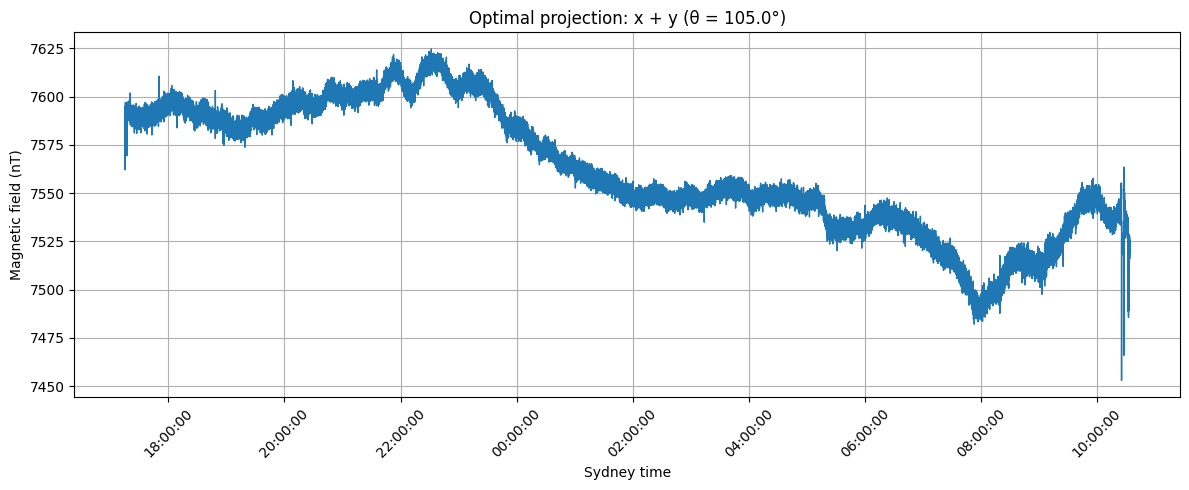

Best theta: 161.6 degrees
Standard deviation: 51.1141 nT
Maximum variance: 2612.6489 nT²


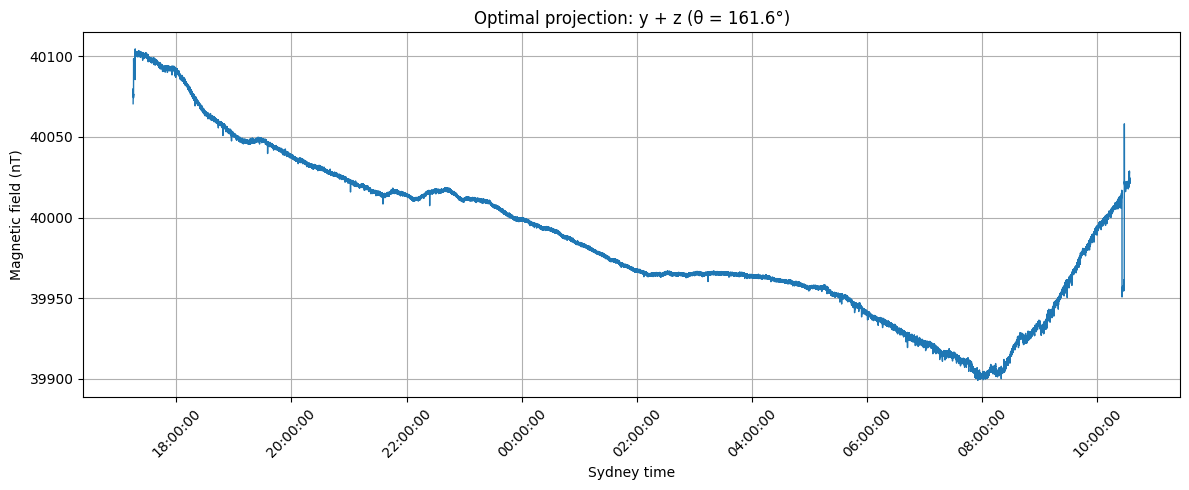

In [69]:
plotTheta(
    "data/3_aug_5_10pm_rm3100_cyc300.h5",
    "x",
    "y",
    calibration=13.0
)

plotTheta(
    "data/3_aug_5_10pm_FLC.h5",
    "y",
    "z"
)

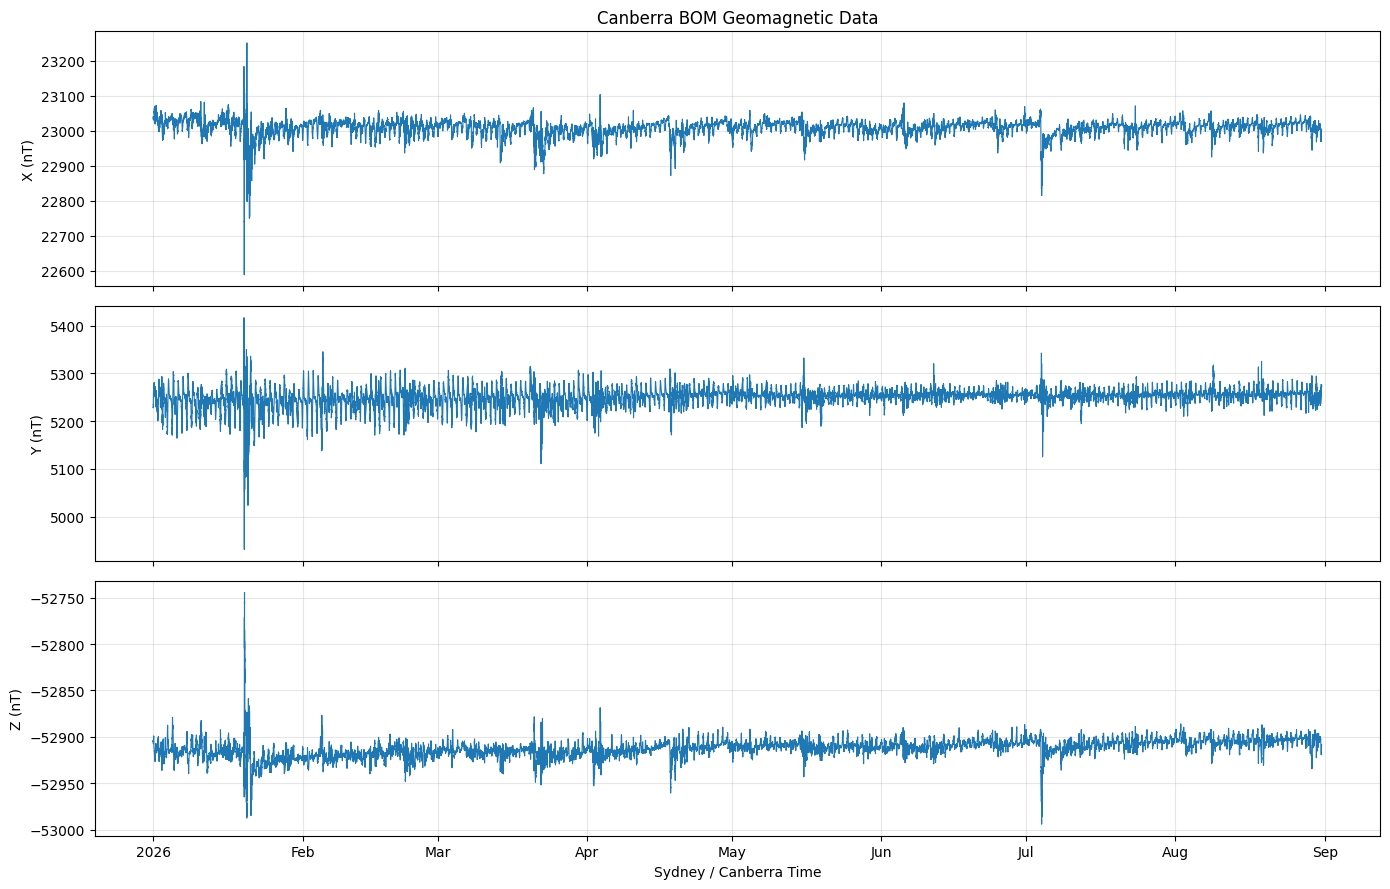

In [70]:
plotBOM("data/2026-bom.csv")

## Plot .h5 Data

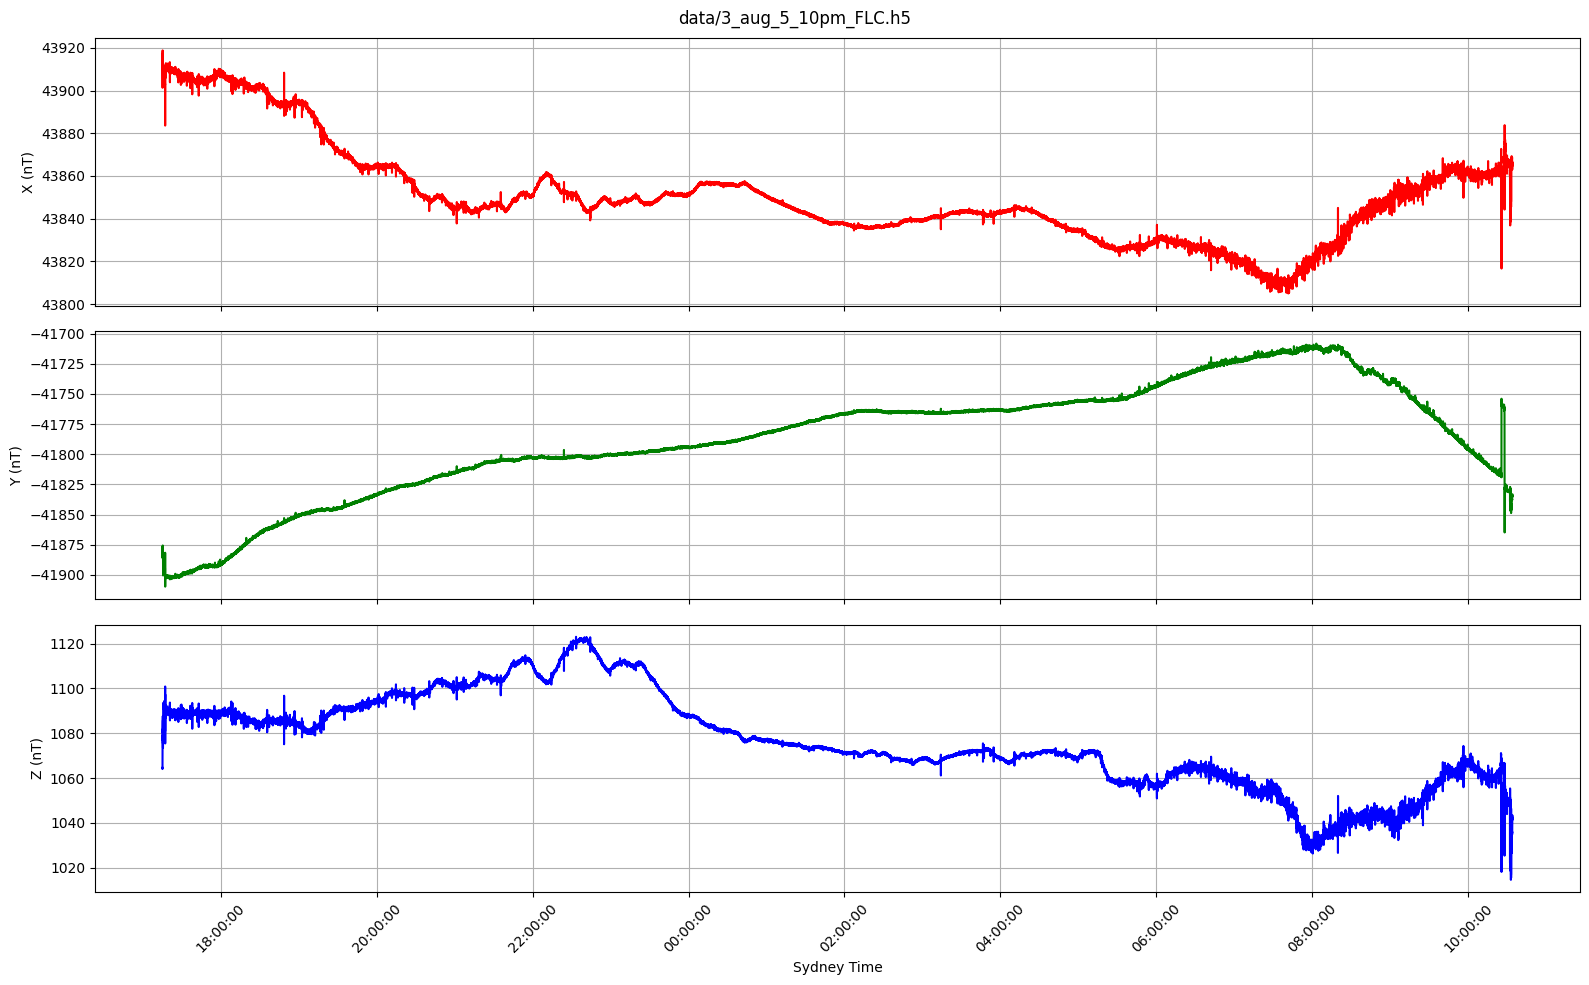

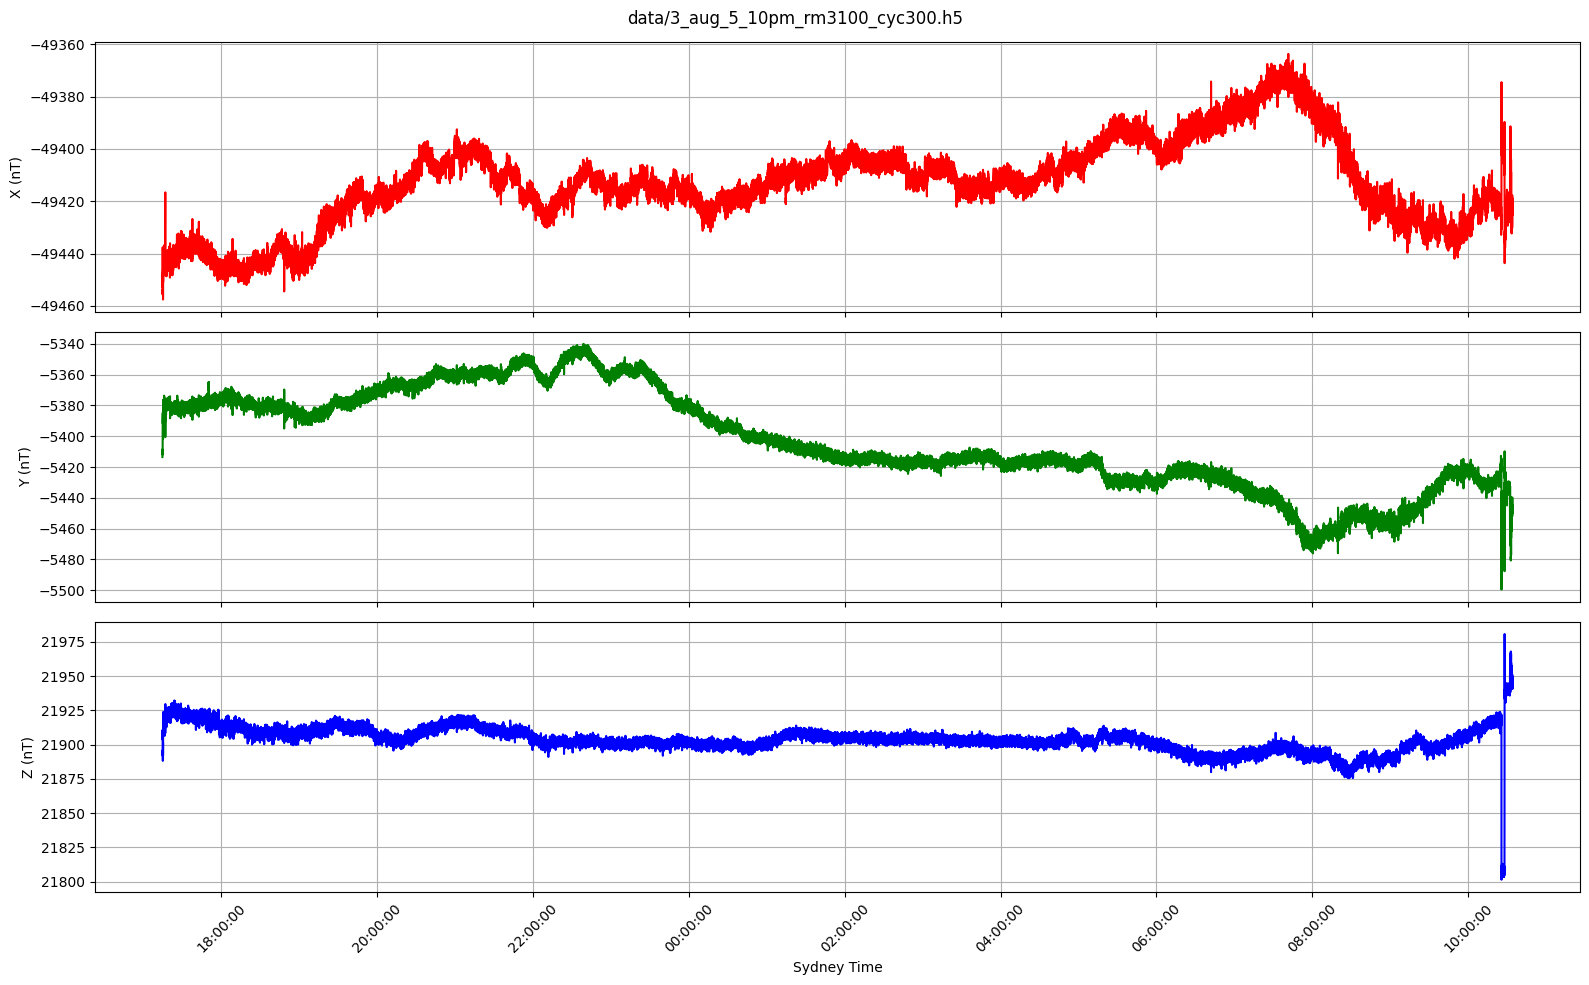

In [71]:
plotAxes(
    "data/3_aug_5_10pm_FLC.h5"
)

plotAxes(
    "data/3_aug_5_10pm_rm3100_cyc300.h5",
    calibration=13.0
)


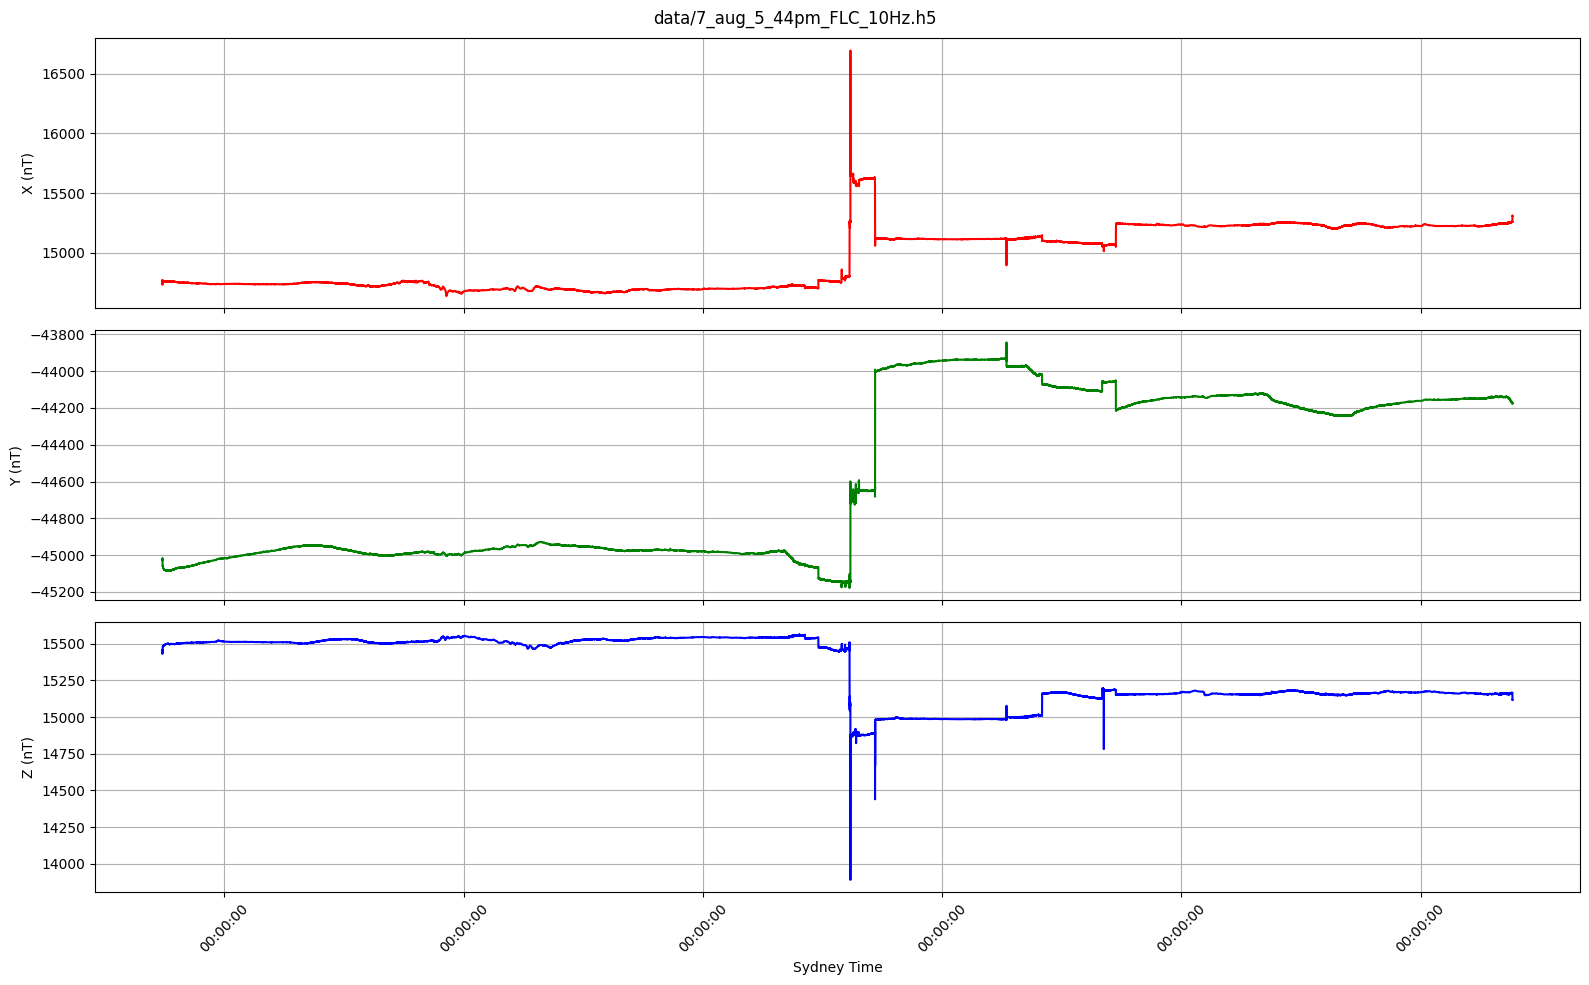

In [72]:
plotAxes("data/7_aug_5_44pm_FLC_10Hz.h5")

## PSD Plots

In [ ]:
for filename, data in all_data.items():

    # Extract data
    FLCX = data["x"]
    FLCY = data["y"]
    FLCZ = data["z"]
    time = data["time"]

    # ---------------------------------------------------------
    # Calculate sampling frequency
    # ---------------------------------------------------------
    dt = np.mean(np.diff(time))
    fs = 1 / dt

    print(f"{filename}: sampling frequency = {fs:.3f} Hz")

    # ---------------------------------------------------------
    # Calculate PSD using Welch's method
    # ---------------------------------------------------------
    freq_x, psd_x = welch(
        FLCX,
        fs=fs,
        nperseg=min(4096, len(FLCX))
    )

    freq_y, psd_y = welch(
        FLCY,
        fs=fs,
        nperseg=min(4096, len(FLCY))
    )

    freq_z, psd_z = welch(
        FLCZ,
        fs=fs,
        nperseg=min(4096, len(FLCZ))
    )

    # ---------------------------------------------------------
    # Create 3 stacked subplots
    # ---------------------------------------------------------
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(10, 10),
        sharex=True
    )

    # ---------------------------------------------------------
    # Plot PSD
    # ---------------------------------------------------------

    # Plot PSD on logarithmic frequency and PSD axes
    ax1.semilogy(
        freq_x[1:],
        psd_x[1:],
        color="red"
    )
    
    ax2.semilogy(
        freq_y[1:],
        psd_y[1:],
        color="green"
    )
    
    ax3.semilogy(
        freq_z[1:],
        psd_z[1:],
        color="blue"
    )
    
    # Labels
    ax1.set_ylabel("X PSD")
    ax2.set_ylabel("Y PSD")
    ax3.set_ylabel("Z PSD")
    ax3.set_xlabel("Frequency (Hz)")
    for ax in (ax1, ax2, ax3):
        ax.set_xlim(0, fs / 2)
    
    # Grid
    for ax in (ax1, ax2, ax3):
        ax.grid(True, which="both")



    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------
    ax1.set_ylabel("X PSD")
    ax2.set_ylabel("Y PSD")
    ax3.set_ylabel("Z PSD")
    ax3.set_xlabel("Frequency (Hz)")

    # Title
    fig.suptitle(filename)

    # Grid
    for ax in (ax1, ax2, ax3):
        ax.grid(True)

    # Hide intermediate x-axis labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)

    plt.tight_layout()
    plt.show()

In [26]:
print("dt =", dt)
print("fs =", fs)
print("Nyquist frequency =", fs / 2)
print("Frequency range =", freq_x[0], "to", freq_x[-1])

dt = 0.008215861891311136
fs = 121.71577531720341
Nyquist frequency = 60.857887658601705
Frequency range = 0.0 to 60.857887658601705


3_aug_5_10pm_FLC
Sampling interval: 0.001000 s
Sampling frequency: 999.627 Hz
Nyquist frequency: 499.813 Hz


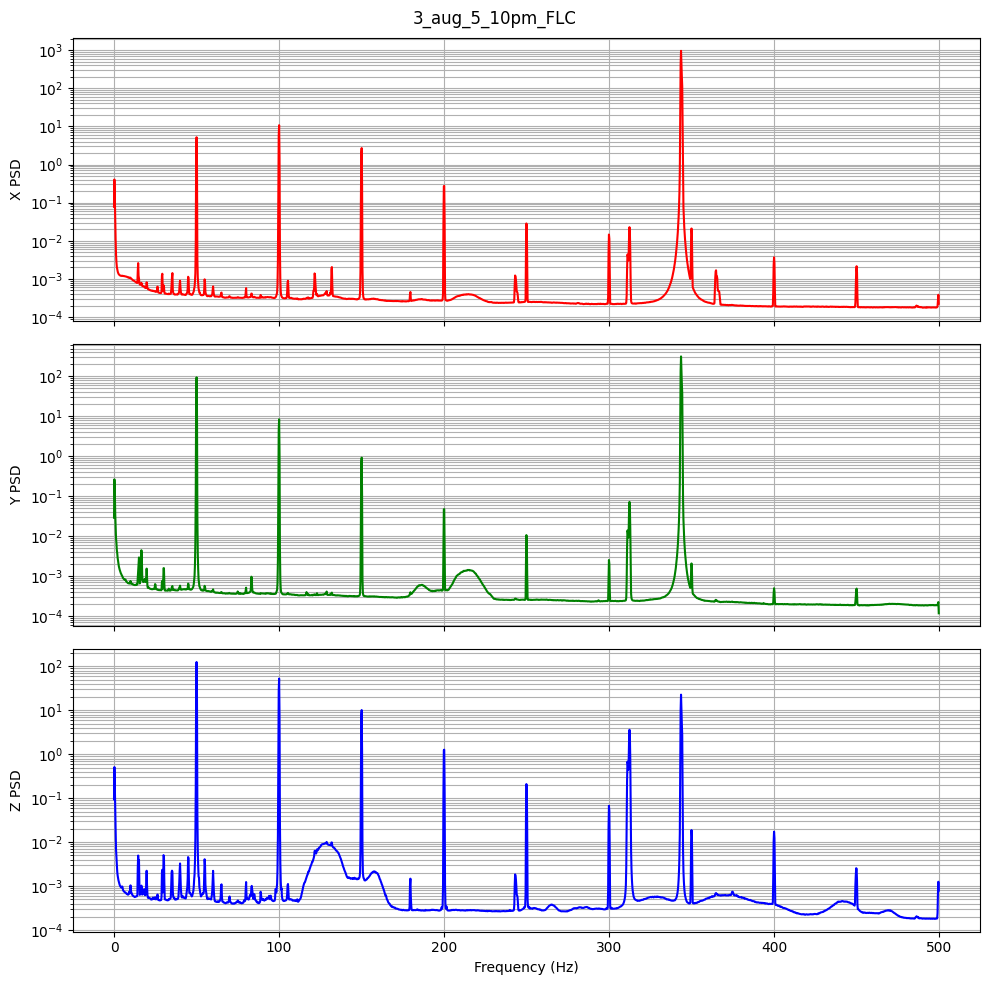

3_aug_5_10pm_rm3100_cyc300
Sampling interval: 0.008216 s
Sampling frequency: 121.716 Hz
Nyquist frequency: 60.858 Hz


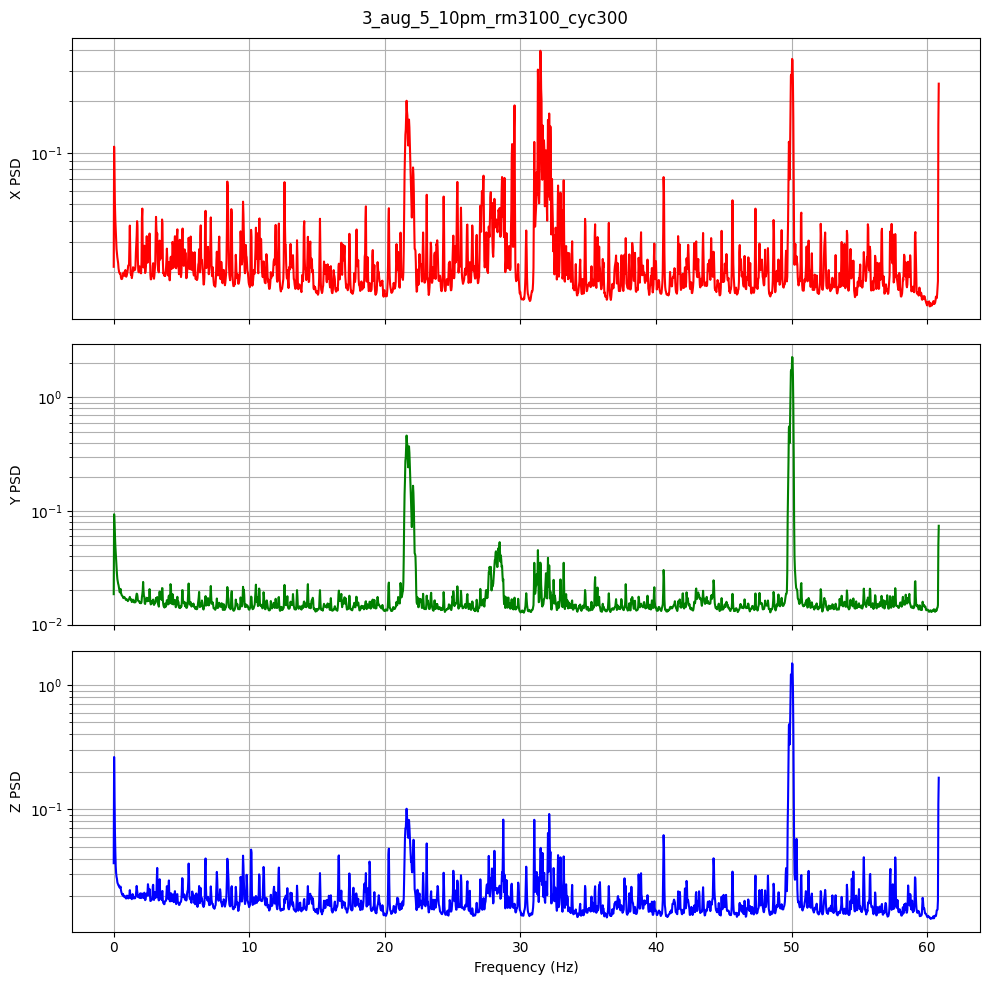

In [27]:
for filename, data in all_data.items():

    FLCX = data["x"]
    FLCY = data["y"]
    FLCZ = data["z"]
    time = data["time"]

    # Sampling interval
    dt = np.mean(np.diff(time))

    # Sampling frequency
    fs = 1 / dt

    print(f"{filename}")
    print(f"Sampling interval: {dt:.6f} s")
    print(f"Sampling frequency: {fs:.3f} Hz")
    print(f"Nyquist frequency: {fs/2:.3f} Hz")

    # PSD
    freq_x, psd_x = welch(
        FLCX,
        fs=fs,
        nperseg=min(4096, len(FLCX))
    )

    freq_y, psd_y = welch(
        FLCY,
        fs=fs,
        nperseg=min(4096, len(FLCY))
    )

    freq_z, psd_z = welch(
        FLCZ,
        fs=fs,
        nperseg=min(4096, len(FLCZ))
    )

    # Plot
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(10, 10),
        sharex=True
    )

    ax1.semilogy(freq_x, psd_x, color="red")
    ax2.semilogy(freq_y, psd_y, color="green")
    ax3.semilogy(freq_z, psd_z, color="blue")

    ax1.set_ylabel("X PSD")
    ax2.set_ylabel("Y PSD")
    ax3.set_ylabel("Z PSD")
    ax3.set_xlabel("Frequency (Hz)")

    fig.suptitle(filename)

    for ax in (ax1, ax2, ax3):
        ax.grid(True, which="both")

    plt.tight_layout()
    plt.show()

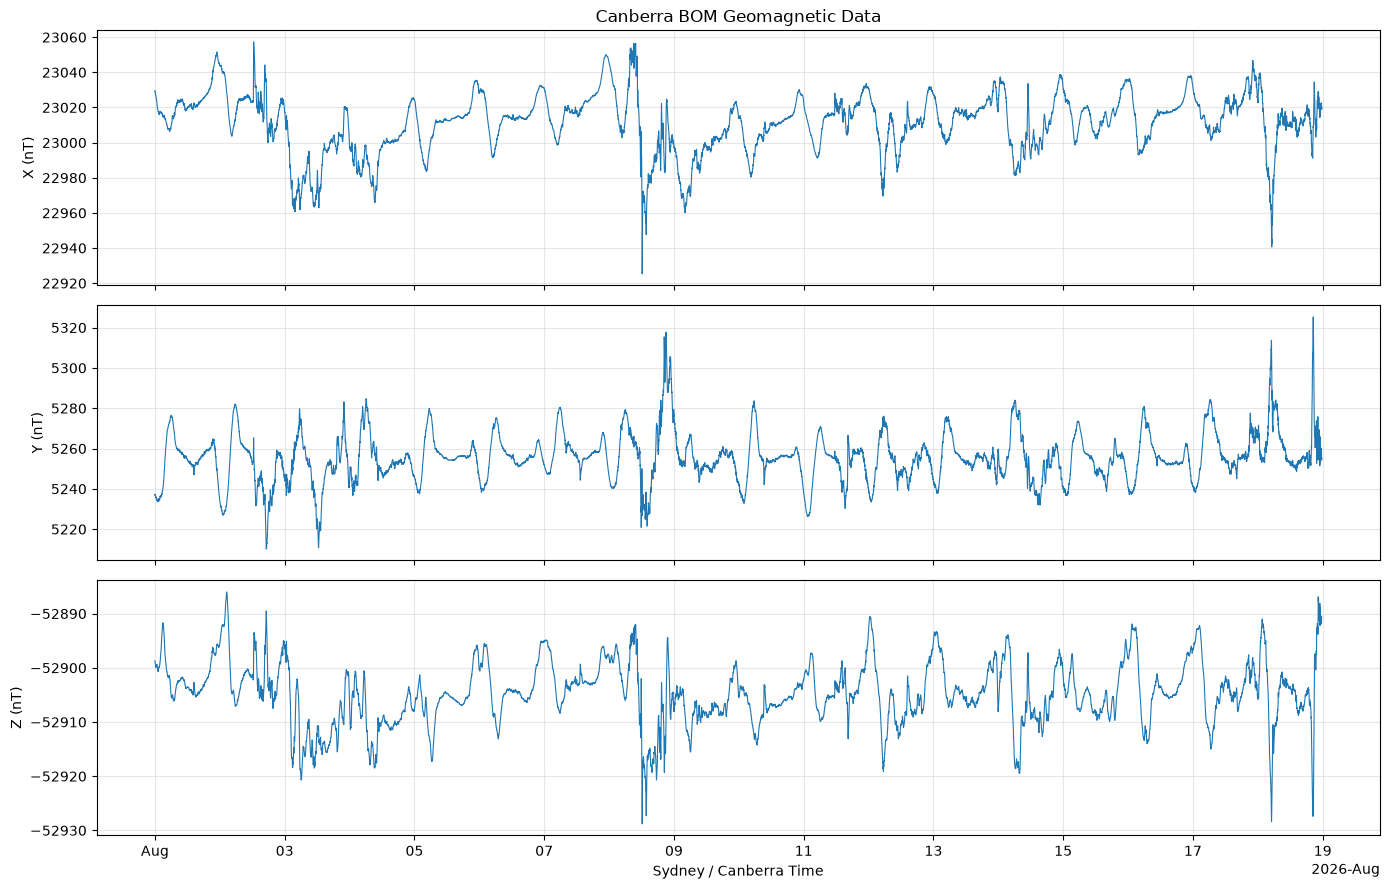

In [48]:
plotBOM("BOM-CNB2.csv")